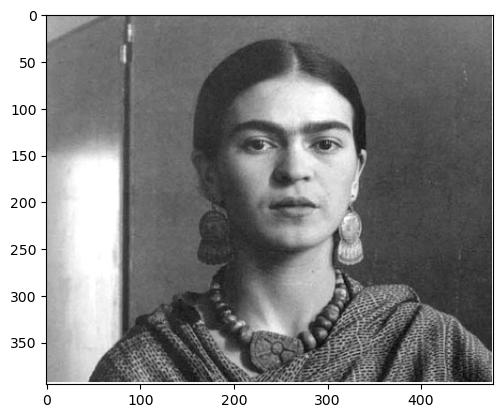

(395, 477)

In [7]:
from skimage.io import imread
import numpy as np
import matplotlib.pylab as plt

A = imread('Week2/Frida.png')  
plt.gray()
plt.imshow(A)          
plt.show()
A.shape

In [13]:
U, Sigma, VT = np.linalg.svd( A )
U.shape, Sigma.shape, VT.shape

((395, 395), (395,), (477, 477))

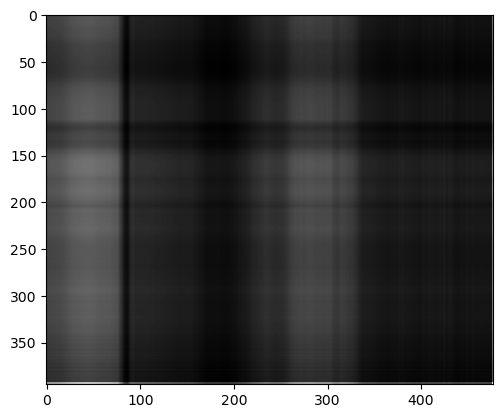

In [15]:
k = 1
B = U[:, :k] * Sigma[:k] @ VT[:k, :] 
plt.imshow(B)

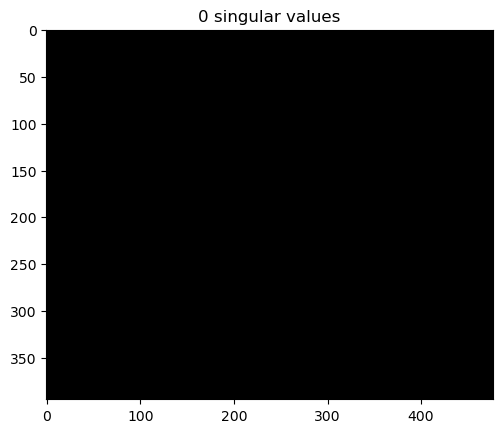

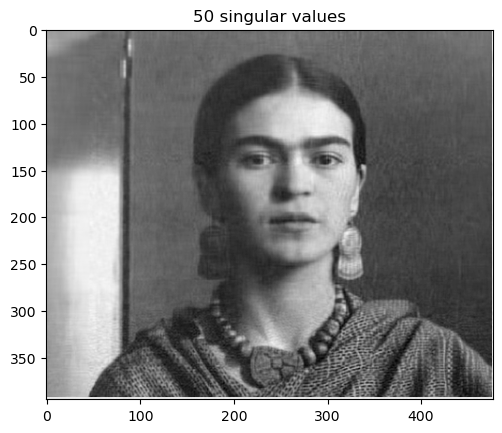

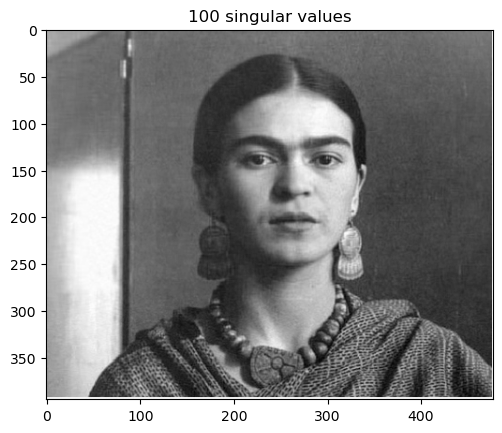

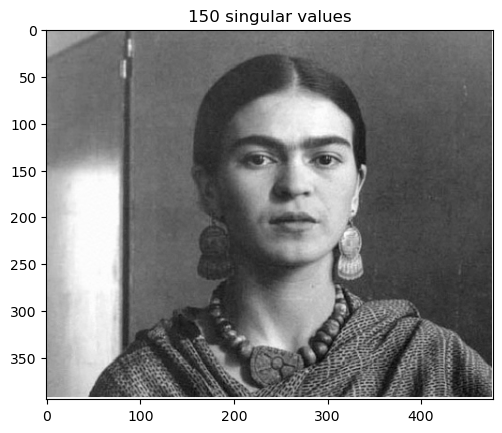

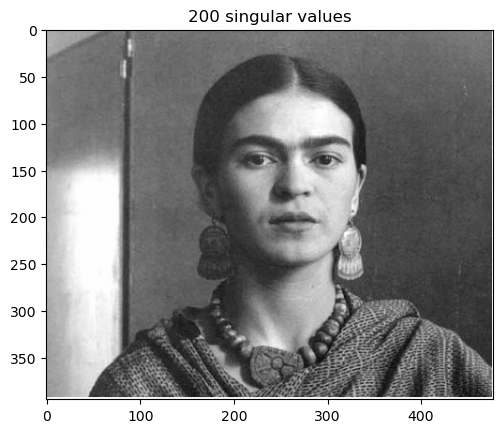

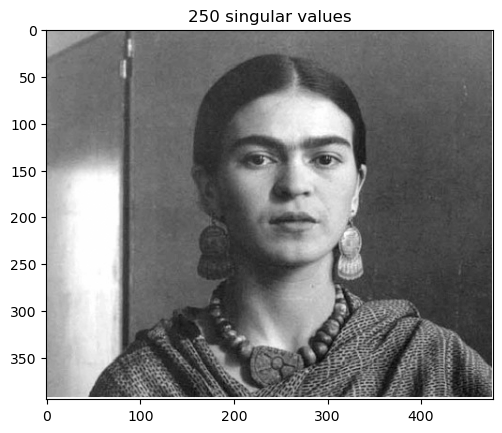

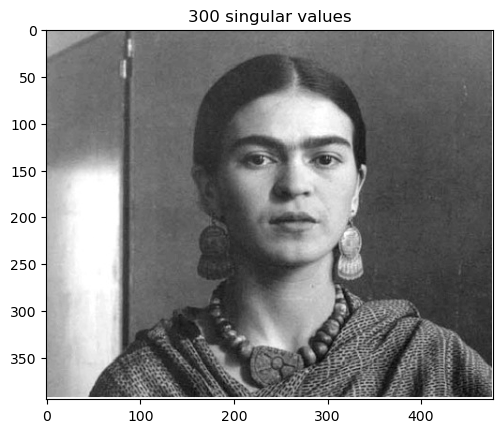

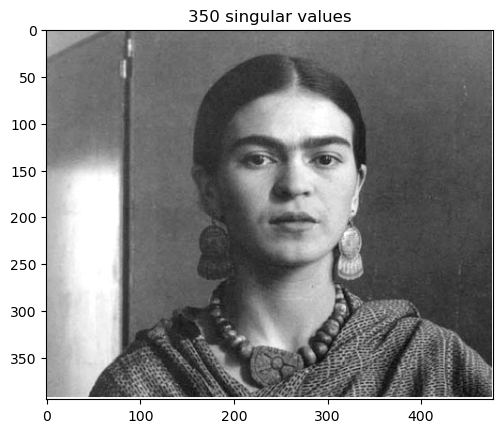

In [16]:
r = min(A.shape)                     
for k in range(0, r, 50):
    plt.imshow(U[:, :k] * Sigma[:k] @ VT[:k, :])
    plt.title(f'{k} singular values')
    plt.show()

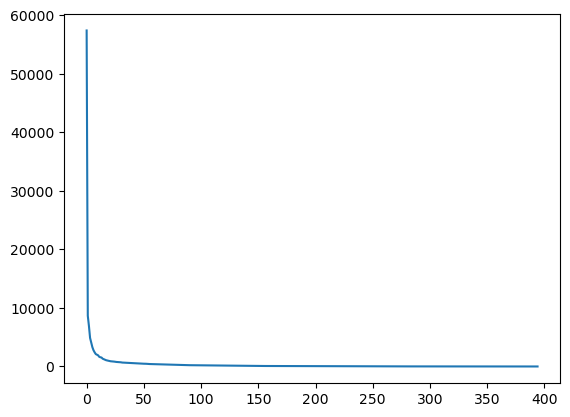

In [17]:
plt.plot(range(r), Sigma)

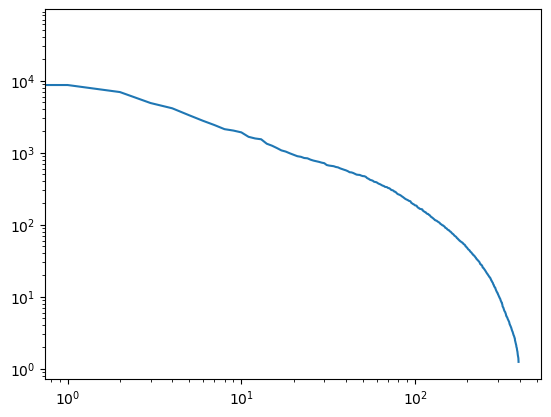

In [18]:
plt.loglog(range(r), Sigma)

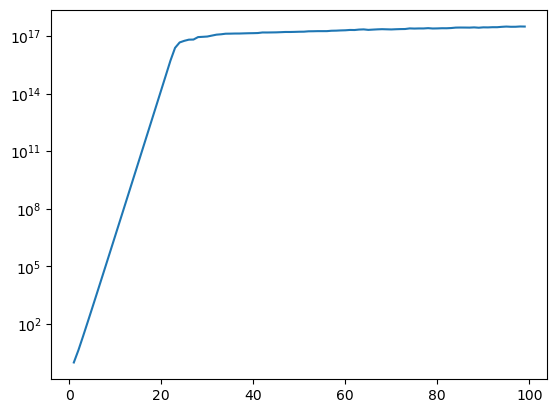

In [24]:
m = 5000
h = 1 / (m-1)
X = np.array([i*h for i in range(m)])
cs = []
for n in range(1, 100):
    M = np.zeros((m, n))
    for i in range(n):
        M[...,i] = X**i
    cs.append(np.linalg.cond(M))
plt.yscale('log')
plt.plot(range(1,100), cs)

In [ ]:
#def P(x, n): # Legendre polynomials
#    return 

In [68]:
A = np.array([[2,-1,1],[-2,2,1],[4,-4,1]])
A1 = np.array([[2,-1,1],[-1,1,2],[2,-2,3]])
L = A1 * np.array([[0,0,0],[1,0,0],[1,1,0]]) + np.eye(3)
U = A1 * np.array([[1,1,1],[0,1,1],[0,0,1]])
L, U, L@U, A

(array([[ 1.,  0.,  0.],
        [-1.,  1.,  0.],
        [ 2., -2.,  1.]]),
 array([[ 2, -1,  1],
        [ 0,  1,  2],
        [ 0,  0,  3]]),
 array([[ 2., -1.,  1.],
        [-2.,  2.,  1.],
        [ 4., -4.,  1.]]),
 array([[ 2, -1,  1],
        [-2,  2,  1],
        [ 4, -4,  1]]))

In [74]:
A = np.array([[2,-1,1],[-4,0,1],[4,0,-2]])
A1 = np.array([[2,-1,1],[-2,-2,3],[2,-1,-1]])
L = A1 * np.array([[0,0,0],[1,0,0],[1,1,0]]) + np.eye(3)
U = A1 * np.array([[1,1,1],[0,1,1],[0,0,1]])
L, U, L@U, A

(array([[ 1.,  0.,  0.],
        [-2.,  1.,  0.],
        [ 2., -1.,  1.]]),
 array([[ 2, -1,  1],
        [ 0, -2,  3],
        [ 0,  0, -1]]),
 array([[ 2., -1.,  1.],
        [-4.,  0.,  1.],
        [ 4.,  0., -2.]]),
 array([[ 2, -1,  1],
        [-4,  0,  1],
        [ 4,  0, -2]]))

In [75]:
b = np.array([-6,2,0])
y =  np.linalg.solve(L, b)
x =  np.linalg.solve(U, y)
print(x)
print(np.linalg.solve(A, b))

[-1.  2. -2.]
[-1.  2. -2.]


In [76]:
from scipy.linalg import lu
A = np.array([[1,0,1],[-1,1,1],[-1,-1,1]])
p, l, u = lu(A)
print(p)
print(l)
print(u)

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
[[ 1.  0.  0.]
 [-1.  1.  0.]
 [-1. -1.  1.]]
[[1. 0. 1.]
 [0. 1. 2.]
 [0. 0. 4.]]


<Axes: >

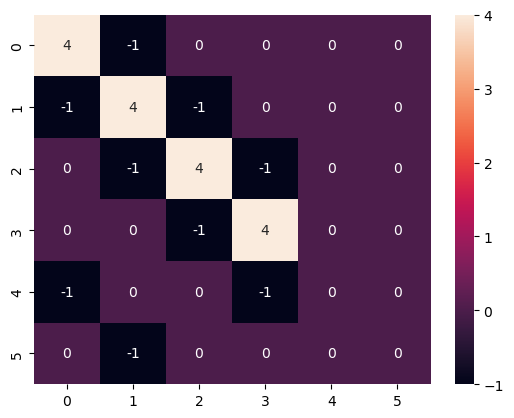

In [80]:
import seaborn as sns

N = 4

def assign(U, i, j, v):
    if j >= 0 and j < N:
        U[i, j] = v

U = np.zeros((N+2,N+2), dtype='int')
for i in range(N+2):
    assign(U, i, i-N, -1) 
    assign(U, i, i-1, -1) 
    assign(U, i, i, 4) 
    assign(U, i, i+1, -1) 
    assign(U, i, i+N, -1) 

sns.heatmap(U, annot=True, fmt="d")

In [130]:
import numpy as np
import matplotlib.animation
import matplotlib.pylab as plt
import seaborn as sns
from matplotlib import cm
plt.style.use('_mpl-gallery')

def F(i, j, a=0.1, b=0.1):
    return (a**2 + b**2)*np.pi**2*np.sin(a*np.pi*i)*np.sin(b*np.pi*j)

def assign(U):
    nr, nc = U.shape
    for i in range(1,N+1):
        for j in range(1,N+1):
            U[i,j] = h**2*F(i,j) 
            if i >= 1: U[i,j] += U[i-1,j]
            if j >= 1: U[i,j] += U[i,j-1]
            if i < nr-1: U[i,j] += U[i+1,j]
            if j < nc-2: U[i,j] += U[i,j+1]
            U[i,j] /= 4
    
N = 20 #100 #16 #4

#while True:
#    o_n = np.linalg.norm(U)
#    assign(U)
#    n_n = np.linalg.norm(U)
#    diff = abs(n_n - o_n)
#    print(diff)
#    if diff < 0.01:
#            break
    
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['figure.dpi'] = 150  
plt.ioff()
fig, ax = plt.subplots()
def animate(t):
    plt.cla()
    U1 = U2.copy()
    o_n = np.linalg.norm(U1)
    assign(U2)
    n_n = np.linalg.norm(U2)
    diff = abs(n_n - o_n)
    #sns.heatmap(U, annot=True, fmt=".1f", cbar=False)
    sns.heatmap(U2, cbar=False)
    plt.title(f'norm={diff:.2f}')
    #plt.show()

#fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
def animate_3d(t):    
    #plt.cla()
    X = np.arange(0, N+2)
    Y = np.arange(0, N+2)
    U1 = U2.copy()
    o_n = np.linalg.norm(U1)
    assign(U2)
    n_n = np.linalg.norm(U2)
    diff = abs(n_n - o_n)
    fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
    ax.plot_surface(X, Y, U2, vmin=U2.min() * 2, cmap=cm.jet)
    ax.set_title(f'norm={diff:.2f}')

U2 = np.zeros((N+2,N+2))
matplotlib.animation.FuncAnimation(fig, animate, frames=20)

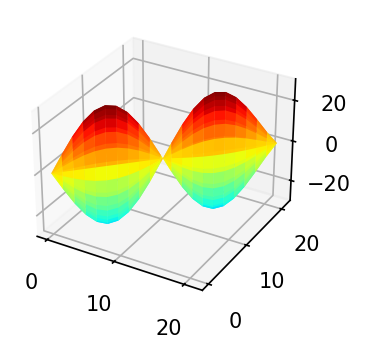

In [126]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import cm

plt.style.use('_mpl-gallery')

# Make data
X = np.arange(0, N+2)
Y = np.arange(0, N+2)

# Plot the surface
plt.close()
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot_surface(X, Y, U, vmin=U.min() * 2, cmap=cm.jet)

#ax.set(xticklabels=[],
#       yticklabels=[],
#       zticklabels=[])

plt.show()

In [134]:
L = np.array([[2,0,0,0],[-1,2,0,0],[0,-1,3,0],[0,0,2,1]])
print(L)
A = L@L.T
print(A)
print(np.linalg.cholesky(A))

[[ 2  0  0  0]
 [-1  2  0  0]
 [ 0 -1  3  0]
 [ 0  0  2  1]]
[[ 4 -2  0  0]
 [-2  5 -2  0]
 [ 0 -2 10  6]
 [ 0  0  6  5]]
[[ 2.  0.  0.  0.]
 [-1.  2.  0.  0.]
 [ 0. -1.  3.  0.]
 [ 0.  0.  2.  1.]]


In [135]:
A = np.array([[2, 0], [0,  -0.5 ]])
np.linalg.eig(A)

EigResult(eigenvalues=array([ 2. , -0.5]), eigenvectors=array([[1., 0.],
       [0., 1.]]))

In [136]:
A = np.array([[2, 1], [0,  -0.5 ]])
np.linalg.eig(A)

EigResult(eigenvalues=array([ 2. , -0.5]), eigenvectors=array([[ 1.        , -0.37139068],
       [ 0.        ,  0.92847669]]))

In [137]:
A = np.array([[2, 1], [1,  -0.5 ]])
np.linalg.eig(A)

EigResult(eigenvalues=array([ 2.35078106, -0.85078106]), eigenvectors=array([[ 0.94362832, -0.33100694],
       [ 0.33100694,  0.94362832]]))

In [139]:
theta = np.pi/4
A = np.array([[np.cos(theta), -np.sin(theta)], [np.sin(theta), np.cos(theta)]])
np.linalg.eig(A)

EigResult(eigenvalues=array([0.70710678+0.70710678j, 0.70710678-0.70710678j]), eigenvectors=array([[0.        +0.70710678j, 0.        -0.70710678j],
       [0.70710678+0.j        , 0.70710678-0.j        ]]))

In [141]:
A = np.array([[2, 1], [0,  2]])
np.linalg.eig(A)

EigResult(eigenvalues=array([2., 2.]), eigenvectors=array([[ 1.0000000e+00, -1.0000000e+00],
       [ 0.0000000e+00,  4.4408921e-16]]))

In [142]:
A = np.array([[2, -1], [-1,  0.5 ]])
np.linalg.eig(A)

EigResult(eigenvalues=array([2.5, 0. ]), eigenvectors=array([[ 0.89442719,  0.4472136 ],
       [-0.4472136 ,  0.89442719]]))

In [143]:
A = np.array([[2, 1.5], [1,  -0.5 ]])
np.linalg.eig(A)

EigResult(eigenvalues=array([ 2.5, -1. ]), eigenvectors=array([[ 0.9486833 , -0.4472136 ],
       [ 0.31622777,  0.89442719]]))

In [144]:
A = np.array([[2, 1], [-1,  0.5 ]])
np.linalg.eig(A)

EigResult(eigenvalues=array([1.25+0.66143783j, 1.25-0.66143783j]), eigenvectors=array([[ 0.70710678+0.j        ,  0.70710678-0.j        ],
       [-0.53033009+0.46770717j, -0.53033009-0.46770717j]]))

In [150]:
A = np.array([[-2,3,-7],[0,1,1],[0,0,2]])
V, X = np.linalg.eig(A)
V, X
A@X, X@np.diag(V)
#np.linalg.solve(X, np.diag(V)@X)
#np.linalg.inv(X)@np.diag(V)@X

(array([[-2.        ,  0.70710678, -1.15470054],
        [ 0.        ,  0.70710678,  1.15470054],
        [ 0.        ,  0.        ,  1.15470054]]),
 array([[-2.        ,  0.70710678, -1.15470054],
        [ 0.        ,  0.70710678,  1.15470054],
        [ 0.        ,  0.        ,  1.15470054]]))

In [154]:
A = np.array([[-1, 2], [2,  3]])
L, Q = np.linalg.eig(A)
Q@np.diag(L)@Q.T

array([[-1.,  2.],
       [ 2.,  3.]])

In [155]:
A = np.array([[2,-1], [-1,2]])
L, Q = np.linalg.eig(A)
Q@np.diag(L)@Q.T

array([[ 2., -1.],
       [-1.,  2.]])